# Week 3.2 — Fiedler Vector via Jacobi Iteration & Eigenvalue Comparison
Connects stationary iterations to spectral graph theory: the Jacobi iteration matrix of a graph Laplacian, deflated of its trivial null-space direction, converges to the Fiedler vector used for spectral graph partitioning.

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

## Part 1: Fiedler vector and Jacobi iteration
Builds the graph Laplacian $L=D-A$ for two triangles joined by a single edge, then computes its eigendecomposition. The eigenvector for the second-smallest eigenvalue (the algebraic connectivity) is the **Fiedler vector**, whose sign pattern reveals the graph's natural two-way split. The Jacobi iteration matrix $G_J=D^{-1}A$ is then power-iterated from a random start, projecting out the mean (the constant eigenvector, which corresponds to eigenvalue 0 and would otherwise dominate) and renormalizing at each step — driving the iterate toward the Fiedler direction.

In [2]:
# Laplacian of two triangles connected by an edge
A = np.array([[0, 1, 1, 0, 0, 0],
              [1, 0, 1, 0, 0, 0],
              [1, 1, 0, 1, 0, 0],
              [0, 0, 1, 0, 1, 1],
              [0, 0, 0, 1, 0, 1],
              [0, 0, 0, 1, 1, 0]])
d = A.sum(axis=1)
D = np.diag(d)
L = D - A

In [3]:
# Eigen-decomposition
Lambda, V = np.linalg.eig(L)
idx = np.argsort(Lambda)
eigs_sorted = Lambda[idx]
V = V[:, idx]

# Fiedler vector (eigenvector for second-smallest eigenvalue)
fiedler = V[:, 1]

print('Fiedler eigenvalue:')
print(eigs_sorted[1])
print('\nFiedler vector:')
print(fiedler)

Fiedler eigenvalue:
0.43844718719116954

Fiedler vector:
[-0.46470513 -0.46470513 -0.26095647  0.26095647  0.46470513  0.46470513]


In [3]:
# Jacobi iteration matrix
GJ = np.linalg.solve(D, A)

# Start from random vector
np.random.seed(0)
x0 = np.random.randn(6)
x0 = x0 / np.linalg.norm(x0)

# Perform iterations
numit = 20
X = np.zeros((6, numit + 1))
X[:, 0] = x0

for k in range(numit):
    X[:, k + 1] = GJ @ X[:, k]
    # Project out the constant vector component and normalize
    X[:, k + 1] = X[:, k + 1] - np.mean(X[:, k + 1])
    X[:, k + 1] = X[:, k + 1] / np.linalg.norm(X[:, k + 1])

(-1.0, 1.0)

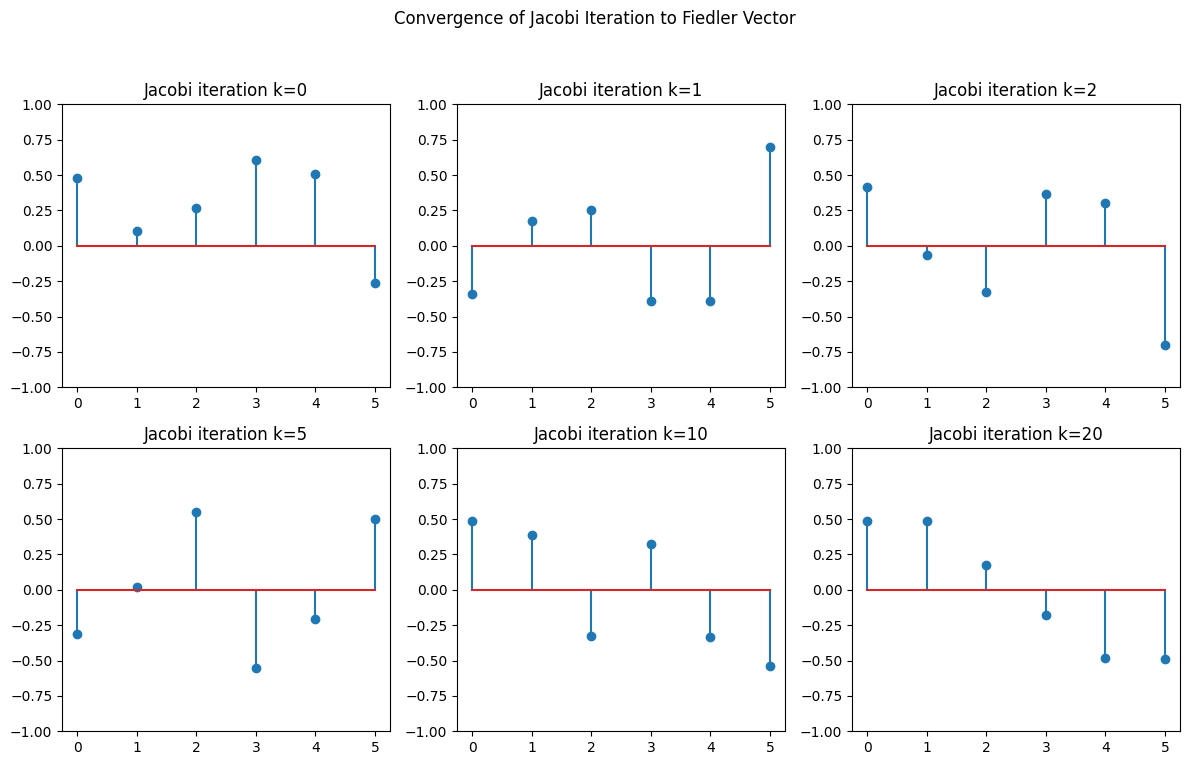

In [ ]:
# Compare with Fiedler vector
plt.figure(figsize=(12, 8))
plot_iters = [0, 1, 2, 5, 10, 20]
for i, k in enumerate(plot_iters):
    plt.subplot(2, 3, i + 1)
    plt.stem(X[:, k])
    plt.title(f'Jacobi iteration k={k}')
    plt.ylim([-1, 1])
plt.suptitle('Convergence of Jacobi Iteration to Fiedler Vector')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Part 2: Comparing eigenvalues of the Poisson matrix with those of P_n
Compares the sorted eigenvalues of the standard Dirichlet 1D Laplacian against a variant `path` matrix with modified corner entries (effectively different boundary conditions at the endpoints), showing how boundary treatment shifts the spectrum.

In [7]:
n = 10
# matrix for Laplacian
Lap = sp.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n)).toarray()

# matrix for P_n
path = sp.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n)).toarray()
path[0, 0] = 1
path[n - 1, n - 1] = 1

Lapeig = np.linalg.eigvalsh(Lap)
patheig = np.linalg.eigvalsh(path)

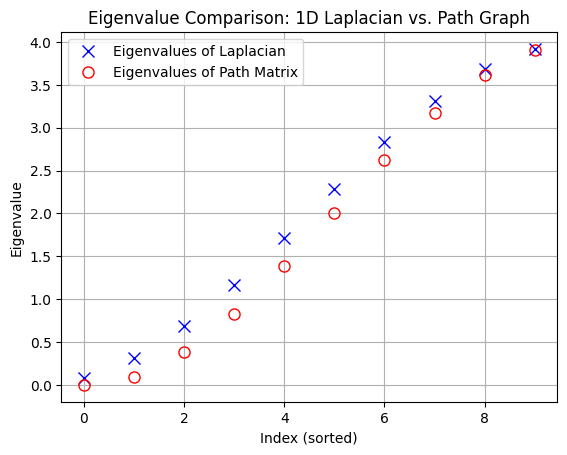

In [8]:
plt.figure()
plt.plot(np.sort(Lapeig), 'bx', markersize=8, label='Eigenvalues of Laplacian')
plt.plot(np.sort(patheig), 'ro', markerfacecolor='none', markersize=8, label='Eigenvalues of Path Matrix')
plt.xlabel('Index (sorted)')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Comparison: 1D Laplacian vs. Path Graph')
plt.legend()
plt.grid(True)
plt.show()